# 1D RM-synthesis weighting

RM-synthesis is a Fourier transform from $\lambda^2$ to Faraday depth $\phi$, so
the RMSF (the response function, analogous to the interferometric dirty beam) is
the Fourier transform of the per-channel *weights* over $\lambda^2$. The channel
sampling in $\lambda^2$ is fixed by the band, but the weights are ours to choose,
exactly like uv weighting in aperture-synthesis imaging.

`rm-lite` provides the interferometric weighting schemes:

| weight_type | definition | interferometric analogue |
| --- | --- | --- |
| `variance` / `natural` | $1/\sigma^2$ | natural (max sensitivity) |
| `uniform` | equal per channel | (no weighting) |
| `uniform_lsq` | equal per $\lambda^2$ interval | uniform (max resolution) |
| `briggs` | robust interpolation | Briggs / robust |

`briggs` spans the range with a single `robust` knob (large positive $\to$
`natural`, large negative $\to$ `uniform_lsq`). We compare **all** of them on a
**Faraday-thick** source observed with realistic **RACS-all** coverage (three
sub-bands with gaps). Banded coverage gives the weighting less leverage than a
filled band, so the RMSF changes here are modest; the important behaviour is that
the $\lambda^2$ weights stay robust across the gaps. Every claim below is checked
with an `assert`.

In [1]:
from __future__ import annotations

import logging

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.visualization import quantity_support
from numpy.typing import NDArray
from rm_lite.tools_1d import rmclean, rmsynth
from rm_lite.utils.logging import quiet_logs
from rm_lite.utils.synthesis import (
    FDFOptions,
    compute_rmsynth_params,
    freq_to_lambda2,
    inverse_rmsynth_nufft,
)

plt.rcParams["figure.dpi"] = 150
_ = quantity_support()
rng = np.random.default_rng(42)

# rm_lite logs each synth/clean run; `with quiet_logs(logging.ERROR):` around the
# runs below keeps the notebook quiet.

# Distinct styles so overlapping traces (e.g. variance and uniform) stay visible.
LINE_STYLES = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 2))]
MARKERS = [".", "x", "+", "^", "s", "d"]

A Burn slab gives the Faraday-thick source; a helper measures the RMSF FWHM.

In [2]:
def faraday_slab_spectrum(
    lambda_sq_arr_m2: NDArray[np.float64],
    frac_pol: float,
    psi0_deg: float,
    rm_radm2: float,
    delta_rm_radm2: float,
) -> NDArray[np.complex128]:
    """Burn slab: a Faraday-thick component of thickness delta_rm."""
    return (
        frac_pol
        * np.exp(2j * (np.deg2rad(psi0_deg) + rm_radm2 * lambda_sq_arr_m2))
        * np.sinc(delta_rm_radm2 * lambda_sq_arr_m2 / np.pi)
    ).astype(np.complex128)


def fwhm_from_curve(phi: NDArray[np.float64], amp: NDArray[np.float64]) -> float:
    """FWHM of the main lobe from the half-maximum crossings (linear interp)."""
    amp = amp / amp.max()
    peak = int(np.argmax(amp))

    def cross(idxs: range) -> float:
        prev = peak
        for i in idxs:
            if amp[i] < 0.5:
                frac = (0.5 - amp[prev]) / (amp[i] - amp[prev])
                return float(phi[prev] + frac * (phi[i] - phi[prev]))
            prev = i
        return float(phi[idxs[-1]])

    return cross(range(peak + 1, len(amp))) - cross(range(peak - 1, -1, -1))

We use realistic **RACS-all** coverage: three separated sub-bands (low, mid,
high) with **gaps** between them. Gaps are where the interferometric-style
weighting has to be careful, so this is the honest test. We place a Faraday-thick
slab (thickness 40 rad/m$^2$) at 40 rad/m$^2$, add noise, and plot the data with
the true model overlaid.

[Text(0.5, 0, '$\\nu$ / $\\mathrm{Hz}$'), Text(0, 0.5, 'Fractional flux')]

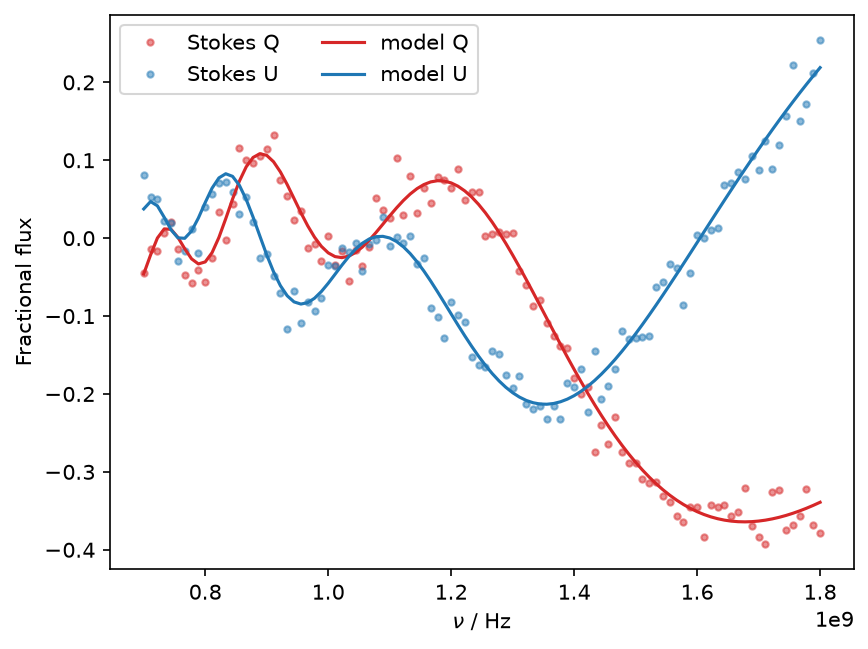

In [15]:
# RACS-all coverage: low/mid/high sub-bands with gaps between them.
bw_low, bw_mid, bw_high = 288.0, 144.0, 288.0
low = np.linspace(943.5 - bw_low / 2, 943.5 + bw_low / 2, 36)
mid = np.linspace(1367.5 - bw_mid / 2, 1367.5 + bw_mid / 2, 9)
high = np.linspace(1655.5 - bw_high / 2, 1655.5 + bw_high / 2, 9)
# freq_hz = (np.concatenate([low, mid, high]) * u.MHz).to(u.Hz).value
freq_hz = np.linspace(700, 1800, 100) * u.MHz.to(u.Hz)  # for testing
lambda_sq = freq_to_lambda2(freq_hz)

rm_radm2 = 40.0
delta_rm_radm2 = 40.0
frac_pol = 0.5
psi0_deg = 10.0
model_kw = {
    "frac_pol": frac_pol,
    "psi0_deg": psi0_deg,
    "rm_radm2": rm_radm2,
    "delta_rm_radm2": delta_rm_radm2,
}
complex_model = faraday_slab_spectrum(lambda_sq, **model_kw)
rms_noise = 0.02
complex_noisy = (
    complex_model
    + rng.normal(0, rms_noise, freq_hz.size)
    + 1j * rng.normal(0, rms_noise, freq_hz.size)
).astype(np.complex128)
complex_err = np.ones_like(complex_noisy) * (rms_noise + rms_noise * 1j)

fig, ax = plt.subplots()
ax.plot(freq_hz, complex_noisy.real, ".", color="tab:red", alpha=0.5, label="Stokes Q")
ax.plot(freq_hz, complex_noisy.imag, ".", color="tab:blue", alpha=0.5, label="Stokes U")
ax.plot(freq_hz, complex_model.real, color="tab:red", label="model Q")
ax.plot(freq_hz, complex_model.imag, color="tab:blue", label="model U")
ax.legend(ncol=2)
ax.set(xlabel=rf"$\nu$ / {u.Hz:latex_inline}", ylabel="Fractional flux")

A helper runs RM-synthesis for one weighting and returns the weights, RMSF and
FDF. `compute_rmsynth_params` exposes the actual per-channel weight array.

In [16]:
def run_weighting(**kw: object) -> dict:
    """Run RM-synthesis for one weighting; collect weights, RMSF, FDF, synth."""
    opts = FDFOptions(n_samples=50, phi_max_radm2=300.0, **kw)  # type: ignore[arg-type]
    params = compute_rmsynth_params(freq_hz, complex_noisy, complex_err, opts)
    synth = rmsynth.run_rmsynth(
        freq_arr_hz=freq_hz,
        complex_pol_arr=complex_noisy,
        complex_pol_error=complex_err,
        n_samples=50,
        phi_max_radm2=300.0,
        **kw,  # type: ignore[arg-type]
    )
    fdf_arrs, rmsf_arrs = synth[1], synth[2]
    phi2 = rmsf_arrs["phi2_arr_radm2"].to_numpy()
    rmsf = np.abs(rmsf_arrs["rmsf_complex_arr"].to_numpy().astype(complex))
    return {
        "synth": synth,
        "weight": params.weight_arr,
        "phi": fdf_arrs["phi_arr_radm2"].to_numpy(),
        "fdf": np.abs(fdf_arrs["fdf_dirty_complex_arr"].to_numpy().astype(complex)),
        "phi2": phi2,
        "rmsf": rmsf,
        "fwhm": fwhm_from_curve(phi2, rmsf),
    }

## How `uniform_lsq` is computed from a non-uniform grid

Interferometric uniform weighting down-weights densely sampled regions so every
part of the band contributes equally. Each channel is weighted by the local
$\lambda^2$ **interval it samples** rather than binned onto a fixed grid (fixed
bins alias against the channel spacing and spike where a bin catches fewer
channels). The interval is the smaller of a channel's two nearest-neighbour gaps
(capped at $\mathrm{cell} = \sqrt{3}/\phi_\mathrm{max}$), then smoothed along
$\lambda^2$ with a Gaussian of bandwidth $2\,\mathrm{cell}$:

$$ w_i \;=\; \mathrm{smooth}\big[\min(\Delta^-_i,\ \Delta^+_i,\ \mathrm{cell})\big], $$

with the smoothing reflected about the band ends. The noise cancels (this is the
`robust` $\to -\infty$ limit of `briggs`), so equal $\lambda^2$ coverage
contributes equally regardless of per-channel noise. Properties:

- **No aliasing spikes.** Using the actual neighbour spacing, not a fixed grid,
  means there is nothing to alias against, so the weight has no random per-channel
  jumps even where the channel spacing approaches the cell.
- **Continuous across sub-band gaps.** The few-cell bandwidth bridges the gaps,
  so the weight is a smooth function of $\lambda^2$ that follows the overall
  trend rather than restarting at each sub-band's dense edge (a jump/rescale at
  every gap); the bandwidth is not so wide as to flatten the trend away.
- **No gap or band-edge spike.** Taking the smaller neighbour gap makes a
  channel bordering a gap take its in-band spacing, not the empty span.

The cell below reproduces the library weights.

In [17]:
phi_max_radm2 = 300.0
cell_m2 = (
    np.sqrt(3.0) / phi_max_radm2
)  # lambda^2 cell (neighbour cap); smooth over 2 cell

# uniform_lsq weight = smoothed nearest-neighbour lambda^2 interval (noise cancels).
order = np.argsort(lambda_sq)
x = lambda_sq[order]
d = np.diff(x)
left = np.empty_like(x)
right = np.empty_like(x)
left[1:], left[0] = d, d[0]
right[:-1], right[-1] = d, d[-1]
spacing = np.minimum(np.minimum(left, right), cell_m2)  # smaller neighbour gap, capped
# Gaussian smoothing (bandwidth 2 cell) along lambda^2, reflected at the ends
bandwidth = 2 * cell_m2
src = np.concatenate([x, 2 * x[0] - x, 2 * x[-1] - x])
src_spacing = np.concatenate([spacing, spacing, spacing])
kern = np.exp(-0.5 * ((x[:, None] - src[None, :]) / bandwidth) ** 2)
smoothed = (kern @ src_spacing) / kern.sum(axis=1)
manual_uniform_lsq = np.empty_like(lambda_sq)
manual_uniform_lsq[order] = smoothed

with quiet_logs(logging.ERROR):
    lsq_weight = compute_rmsynth_params(
        freq_hz,
        complex_noisy,
        complex_err,
        FDFOptions(
            n_samples=50, phi_max_radm2=phi_max_radm2, weight_type="uniform_lsq"
        ),
    ).weight_arr
np.testing.assert_allclose(
    manual_uniform_lsq / manual_uniform_lsq.sum(), lsq_weight / lsq_weight.sum()
)
print("uniform_lsq reproduced from the smoothed lambda^2 interval.")

# Continuous across gaps (no per-sub-band reset) and no per-channel spikes, while
# the overall trend (dynamic range) is retained.
adjacent = np.maximum(smoothed[1:], smoothed[:-1]) / np.minimum(
    smoothed[1:], smoothed[:-1]
)
assert adjacent.max() < 1.15, "smooth, no gap reset or spike"
assert smoothed.max() / smoothed.min() > 1.8, "overall trend retained"
print(f"largest adjacent weight ratio = {adjacent.max():.2f}")

uniform_lsq reproduced from the smoothed lambda^2 interval.
largest adjacent weight ratio = 1.05


## Run every weighting

We run all the schemes once and reuse them in every plot below: `variance` and
`uniform` (which coincide here because the noise is flat), `uniform_lsq`, and
`briggs` at `robust` $= -1, 0, +1$.

In [18]:
weightings = {
    "variance": {"weight_type": "variance"},
    "uniform": {"weight_type": "uniform"},
    "uniform_lsq": {"weight_type": "uniform_lsq"},
    "briggs r=-1": {"weight_type": "briggs", "robust": -1.0},
    "briggs r=0": {"weight_type": "briggs", "robust": 0.0},
    "briggs r=+1": {"weight_type": "briggs", "robust": 1.0},
}
with quiet_logs(logging.ERROR):
    results = {label: run_weighting(**kw) for label, kw in weightings.items()}

for label, res in results.items():
    w = res["weight"] / np.nansum(res["weight"])
    print(f"{label}: {w}")

variance: [0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01]
uniform: [0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 

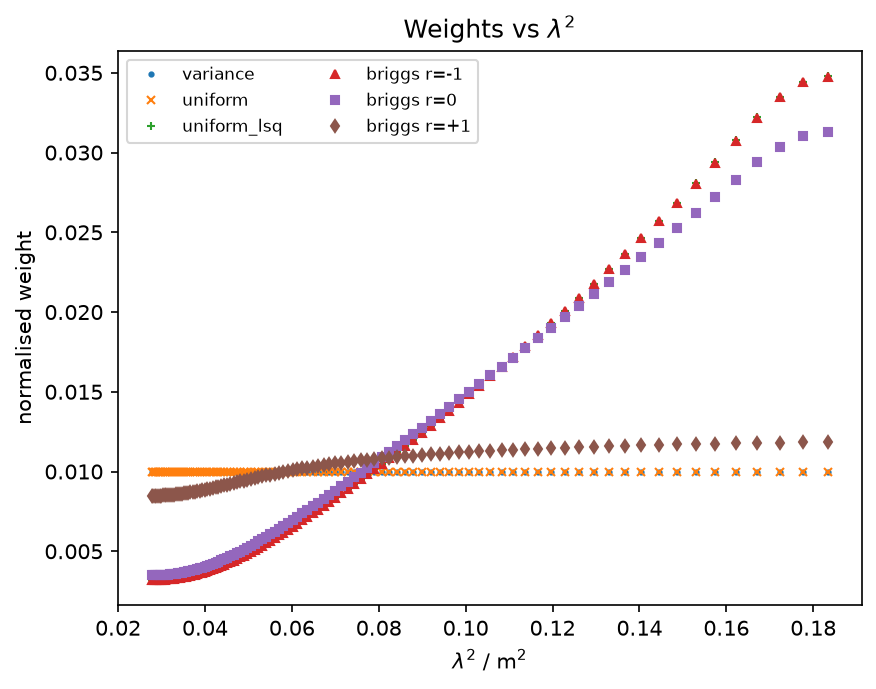

In [19]:
weightings = {
    "variance": {"weight_type": "variance"},
    "uniform": {"weight_type": "uniform"},
    "uniform_lsq": {"weight_type": "uniform_lsq"},
    "briggs r=-1": {"weight_type": "briggs", "robust": -1.0},
    "briggs r=0": {"weight_type": "briggs", "robust": 0.0},
    "briggs r=+1": {"weight_type": "briggs", "robust": 1.0},
}
with quiet_logs(logging.ERROR):
    results = {label: run_weighting(**kw) for label, kw in weightings.items()}

# Weights vs lambda^2: uniform_lsq / low-robust up-weight the sparse large-lambda^2 end.
fig, ax = plt.subplots()
for (label, res), marker in zip(results.items(), MARKERS, strict=False):
    w = res["weight"] / np.nansum(res["weight"])
    ax.plot(lambda_sq, w, marker, ms=4, ls="none", label=label)
ax.set(
    xlabel=rf"$\lambda^2$ / {u.m**2:latex_inline}",
    ylabel="normalised weight",
    title=r"Weights vs $\lambda^2$",
)
ax.legend(ncol=2, fontsize="small")

### RMSF

`uniform_lsq` (and low-robust `briggs`) narrow the RMSF main lobe; `variance`,
`uniform` and high-robust `briggs` are the widest, most sensitive response. With
RACS-all's banded coverage the weighting has little leverage, so the narrowing is
only ~1% (a fraction of a rad/m$^2$) and the intermediate `briggs` points are not
strictly monotonic at that level; the endpoints (`natural` widest, `uniform_lsq`
narrowest) are the robust ordering.

variance     RMSF FWHM =  30.96 rad/m^2
uniform      RMSF FWHM =  30.96 rad/m^2
uniform_lsq  RMSF FWHM =  23.64 rad/m^2
briggs r=-1  RMSF FWHM =  23.65 rad/m^2
briggs r=0   RMSF FWHM =  23.72 rad/m^2
briggs r=+1  RMSF FWHM =  28.40 rad/m^2
RMSF weighting checks passed.


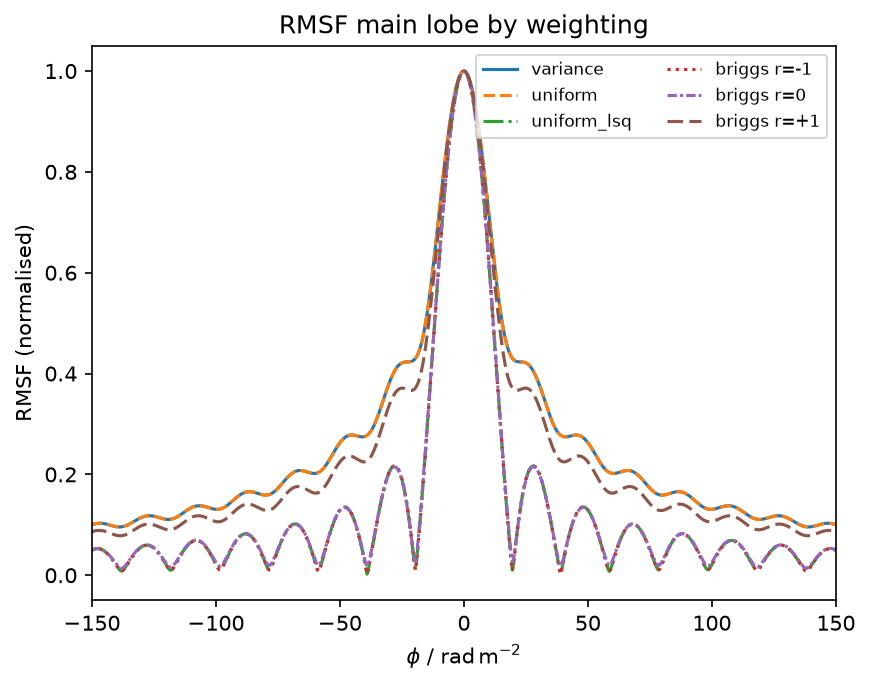

In [21]:
fig, ax = plt.subplots()
for (label, res), ls in zip(results.items(), LINE_STYLES, strict=False):
    ax.plot(res["phi2"], res["rmsf"] / res["rmsf"].max(), ls=ls, label=label)
    print(f"{label:12s} RMSF FWHM = {res['fwhm']:6.2f} rad/m^2")
ax.set(
    xlim=(-150, 150),
    xlabel=rf"$\phi$ / {u.rad / u.m**2:latex_inline}",
    ylabel="RMSF (normalised)",
    title="RMSF main lobe by weighting",
)
ax.legend(ncol=2, fontsize="small")

fwhm = {label: res["fwhm"] for label, res in results.items()}
assert abs(fwhm["variance"] - fwhm["uniform"]) < 0.5, "flat noise: natural == uniform"
assert fwhm["uniform_lsq"] < fwhm["uniform"], "uniform_lsq narrows the RMSF"
# endpoints: high robust -> natural (widest), low robust -> uniform_lsq (narrowest).
# banded coverage gives ~1% leverage, so the intermediate points are only ordered
# to a small tolerance.
tol = 0.1
assert fwhm["briggs r=+1"] <= fwhm["variance"] + tol
assert fwhm["briggs r=-1"] <= fwhm["briggs r=+1"] + tol
assert fwhm["uniform_lsq"] <= fwhm["briggs r=-1"] + tol
print("RMSF weighting checks passed.")

### Dirty FDF vs the model slab

The true Faraday dispersion of a Burn slab is a top-hat over
$[\mathrm{RM}-\Delta/2,\ \mathrm{RM}+\Delta/2]$. The dirty FDF is that top-hat
blurred by the RMSF, so the narrower-RMSF weightings give sharper slab edges.

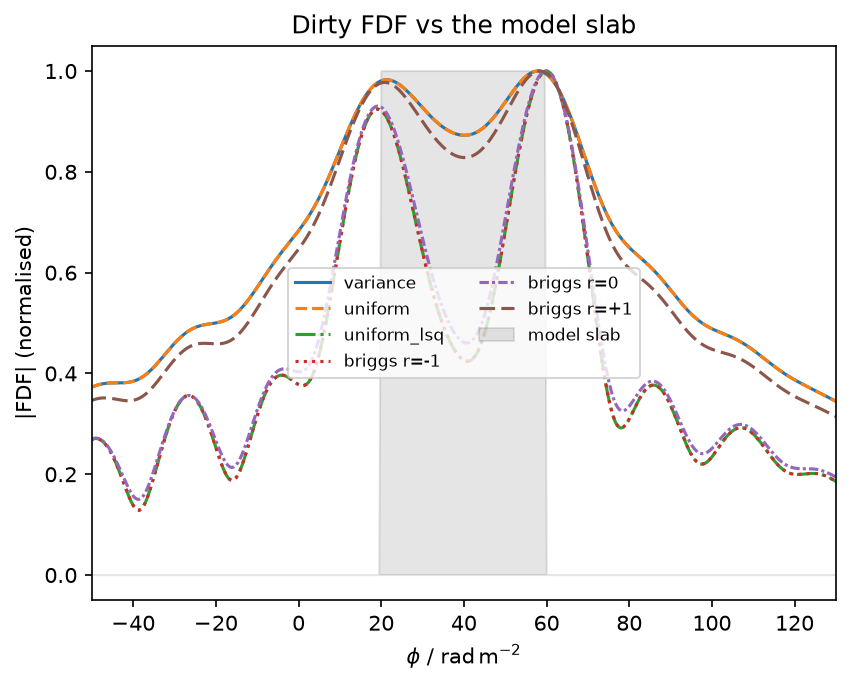

In [22]:
phi_ref = results["variance"]["phi"]
model_tophat = (np.abs(phi_ref - rm_radm2) <= delta_rm_radm2 / 2).astype(float)

fig, ax = plt.subplots()
for (label, res), ls in zip(results.items(), LINE_STYLES, strict=False):
    ax.plot(res["phi"], res["fdf"] / res["fdf"].max(), ls=ls, label=label)
ax.fill_between(phi_ref, model_tophat, color="k", alpha=0.1, label="model slab")
ax.set(
    xlim=(-50, 130),
    xlabel=rf"$\phi$ / {u.rad / u.m**2:latex_inline}",
    ylabel="|FDF| (normalised)",
    title="Dirty FDF vs the model slab",
)
ax.legend(ncol=2, fontsize="small")

### RM-CLEAN: recovered flux and the resolution/sensitivity trade

For a symmetric slab the **flux-weighted mean $\phi$** locates the source, and the
debiased zeroth moment `mom0_debias` measures the **recovered polarised flux**.
Every weighting recovers the slab centre, but the high-resolution weightings
recover *less* faint flux at a fixed threshold: resolution costs sensitivity.

-- CLEAN: mean RM and recovered polarised flux (mom0_debias) --
variance     mean RM =  39.89 (truth 40.0) | mom0 = 0.281
uniform      mean RM =  39.89 (truth 40.0) | mom0 = 0.281
uniform_lsq  mean RM =  38.54 (truth 40.0) | mom0 = 0.145
briggs r=-1  mean RM =  38.49 (truth 40.0) | mom0 = 0.145
briggs r=0   mean RM =  38.87 (truth 40.0) | mom0 = 0.152
briggs r=+1  mean RM =  39.90 (truth 40.0) | mom0 = 0.262
CLEAN checks passed.


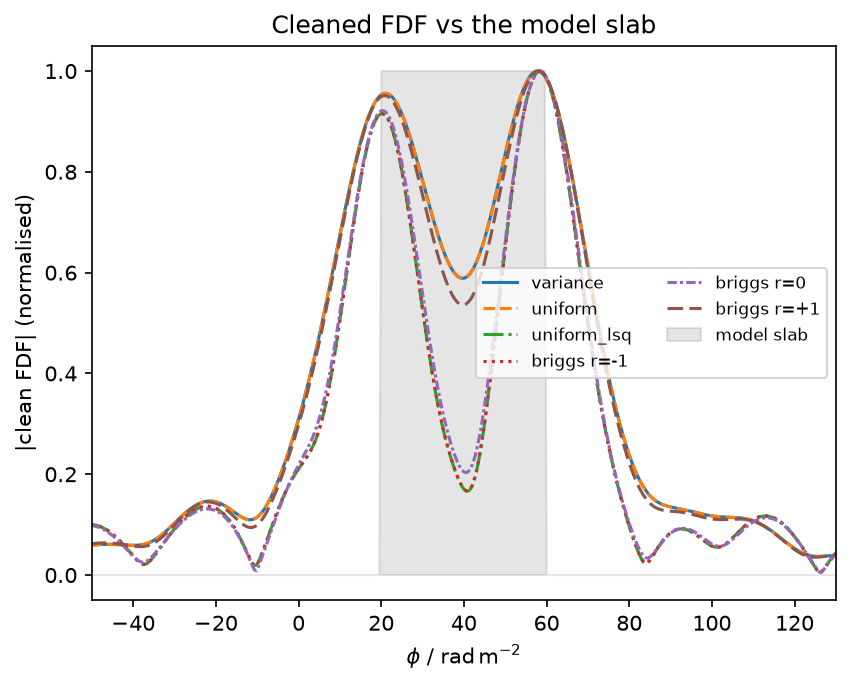

In [23]:
print("-- CLEAN: mean RM and recovered polarised flux (mom0_debias) --")
fig, ax = plt.subplots()
recovered_flux = {}
cleaned = {}
with quiet_logs(logging.ERROR):
    for (label, res), ls in zip(results.items(), LINE_STYLES, strict=False):
        clean = rmclean.run_rmclean_from_synth(
            rm_synth_1d_results=res["synth"], auto_mask=8, auto_threshold=1.0
        )
        cleaned[label] = clean
        arrs = clean.fdf_arrs
        phi = arrs["phi_arr_radm2"].to_numpy()
        clean_fdf = np.abs(arrs["fdf_clean_complex_arr"].to_numpy().astype(complex))
        model = np.abs(arrs["fdf_model_complex_arr"].to_numpy().astype(complex))
        mean_rm = float(np.sum(phi * model) / np.sum(model))
        mom0 = float(clean.fdf_parameters["mom0_debias"][0])
        recovered_flux[label] = mom0
        print(
            f"{label:12s} mean RM = {mean_rm:6.2f} (truth {rm_radm2}) | mom0 = {mom0:.3f}"
        )
        assert abs(mean_rm - rm_radm2) < 5.0, "CLEAN recovers the slab centre"
        ax.plot(phi, clean_fdf / clean_fdf.max(), ls=ls, label=label)
ax.fill_between(phi, model_tophat, color="k", alpha=0.1, label="model slab")
ax.set(
    xlim=(-50, 130),
    xlabel=rf"$\phi$ / {u.rad / u.m**2:latex_inline}",
    ylabel="|clean FDF| (normalised)",
    title="Cleaned FDF vs the model slab",
)
ax.legend(ncol=2, fontsize="small")

assert recovered_flux["variance"] >= recovered_flux["uniform_lsq"]
print("CLEAN checks passed.")

The recovered `mom0` compared with the true input polarised fraction
($\mathrm{mom0}_\mathrm{true} = f_\mathrm{pol} = 0.5$, the integrated
polarisation of the slab). Every weighting under-recovers the diffuse thick
source at this threshold, and the higher-resolution weightings recover the
least.

In [24]:
import polars as pl

flux_table = pl.DataFrame(
    {
        "weighting": list(recovered_flux),
        "mom0_recovered": list(recovered_flux.values()),
        "mom0_true": frac_pol,
    }
).with_columns(
    (pl.col("mom0_recovered") / pl.col("mom0_true")).alias("fraction_recovered")
)
flux_table

weighting,mom0_recovered,mom0_true,fraction_recovered
str,f64,f64,f64
"""variance""",0.280634,0.5,0.561268
"""uniform""",0.280634,0.5,0.561268
"""uniform_lsq""",0.144831,0.5,0.289663
"""briggs r=-1""",0.144948,0.5,0.289895
"""briggs r=0""",0.152163,0.5,0.304327
"""briggs r=+1""",0.262019,0.5,0.524038


### Depolarisation vs slab width and the Faraday max-scale

RM-synthesis is blind to Faraday structure broader than the **max-scale**,
$\phi_\mathrm{max\text{-}scale} \approx \pi / \lambda^2_\mathrm{min}$ (set by
the shortest wavelength, i.e. the top of the band). A Burn slab thicker than this
is resolved out and depolarises. Each slab is normalised to the **same total
polarised flux** (the integral over Faraday depth), so its height scales as
$f_\mathrm{pol}/\Delta$; that total is $|P(\lambda^2{=}0)| = f_\mathrm{pol}$
in this `sinc` model, independent of width. We sweep `robust` from $-2$ to $+2$
and plot the recovered debiased `mom0` for each width. Wider slabs sit lower
(more depolarised); the dashed line is the input flux.

Faraday max-scale ~ 113 rad/m^2
Depolarisation checks passed.


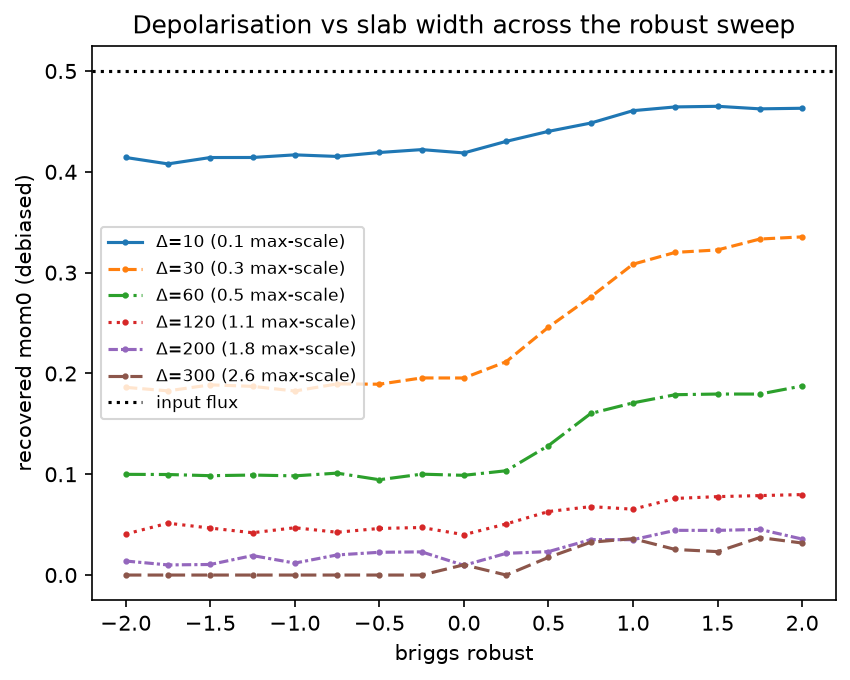

In [25]:
faraday_max_scale = float(np.pi / lambda_sq.min())
print(f"Faraday max-scale ~ {faraday_max_scale:.0f} rad/m^2")


def recover_mom0(delta_rm_radm2: float, robust: float) -> float:
    """Recovered debiased mom0 for a slab of given width and briggs robust."""
    model = faraday_slab_spectrum(
        lambda_sq, frac_pol, psi0_deg, rm_radm2, delta_rm_radm2
    )
    noisy = (
        model
        + rng.normal(0, rms_noise, freq_hz.size)
        + 1j * rng.normal(0, rms_noise, freq_hz.size)
    ).astype(np.complex128)
    err = np.ones_like(noisy) * (rms_noise + rms_noise * 1j)
    synth = rmsynth.run_rmsynth(
        freq_arr_hz=freq_hz,
        complex_pol_arr=noisy,
        complex_pol_error=err,
        n_samples=50,
        phi_max_radm2=400.0,
        weight_type="briggs",
        robust=robust,
    )
    clean = rmclean.run_rmclean_from_synth(
        rm_synth_1d_results=synth, auto_mask=8, auto_threshold=1.0
    )
    return float(clean.fdf_parameters["mom0_debias"][0])


robust_grid = np.arange(-2.0, 2.0 + 1e-6, 0.25)
slab_widths = [10.0, 30.0, 60.0, 120.0, 200.0, 300.0]
mom0_grid = {}
with quiet_logs(logging.ERROR):  # keep the many synth/clean runs quiet
    for width in slab_widths:
        mom0_grid[width] = [recover_mom0(width, r) for r in robust_grid]

fig, ax = plt.subplots()
for (width, mom0), ls in zip(mom0_grid.items(), LINE_STYLES, strict=False):
    ax.plot(
        robust_grid,
        mom0,
        ls=ls,
        marker=".",
        ms=4,
        label=rf"$\Delta$={width:.0f} ({width / faraday_max_scale:.1f} max-scale)",
    )
ax.axhline(frac_pol, color="k", ls=":", label="input flux")
ax.set(
    xlabel="briggs robust",
    ylabel="recovered mom0 (debiased)",
    title="Depolarisation vs slab width across the robust sweep",
)
ax.legend(fontsize="small")

# Thin slabs are recovered; slabs wider than the max-scale depolarise away.
assert max(mom0_grid[slab_widths[0]]) > 0.6 * frac_pol, "thin slab recovered"
assert max(mom0_grid[slab_widths[-1]]) < 0.25 * frac_pol, "wide slab depolarised"
print("Depolarisation checks passed.")

### Extrapolating each clean model back to $\lambda^2 = 0$

Inverse RM-synthesis turns each clean model FDF back into $Q/U$ over $\lambda^2$.
On a contiguous grid from $0$ (the intrinsic, unrotated polarisation) to the band
maximum, comparing with the true model shows: **in band** the reconstruction
tracks the model for every weighting (to within the noise); **at $\lambda^2 =
0$**, well outside the band, a Faraday-thick model is unconstrained and diverges
from the truth.

variance     in-band reconstruction RMS = 0.0189
uniform      in-band reconstruction RMS = 0.0189
uniform_lsq  in-band reconstruction RMS = 0.0226
briggs r=-1  in-band reconstruction RMS = 0.0227
briggs r=0   in-band reconstruction RMS = 0.0219
briggs r=+1  in-band reconstruction RMS = 0.0184
Extrapolation checks passed.


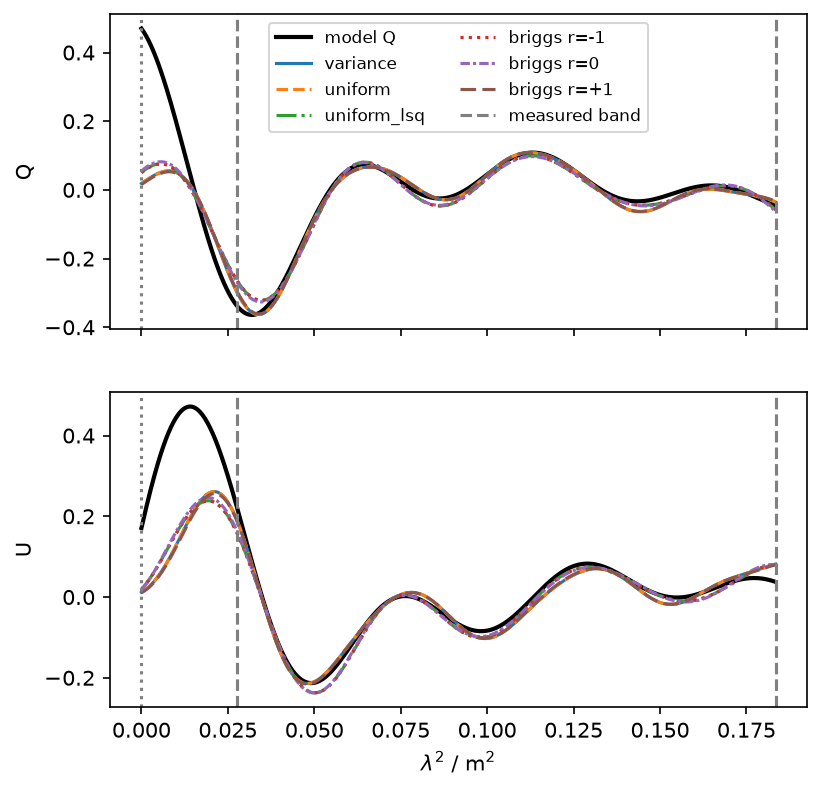

In [26]:
# Contiguous lambda^2 grid from 0 to the band maximum (the observed samples
# are irregular; a dense grid gives smooth reconstruction curves).
lambda_sq_ext = np.linspace(0.0, lambda_sq.max(), 500)
model_ext = faraday_slab_spectrum(lambda_sq_ext, **model_kw)
in_band = (lambda_sq_ext >= lambda_sq.min()) & (lambda_sq_ext <= lambda_sq.max())

fig, (ax0, ax1) = plt.subplots(2, 1, sharex=True, figsize=(6, 6))
ax0.plot(lambda_sq_ext, model_ext.real, "k", lw=2, label="model Q")
ax1.plot(lambda_sq_ext, model_ext.imag, "k", lw=2, label="model U")
band_rms = {}
with quiet_logs(logging.ERROR):
    for (label, clean), ls in zip(cleaned.items(), LINE_STYLES, strict=False):
        arrs = clean.fdf_arrs
        phi = arrs["phi_arr_radm2"].to_numpy()
        fdf_model = arrs["fdf_model_complex_arr"].to_numpy().astype(complex)
        lam0 = float(clean.fdf_parameters["lam_sq_0_m2"][0])
        recon = inverse_rmsynth_nufft(fdf_model, lambda_sq_ext, phi, lam0)
        band_rms[label] = float(
            np.sqrt(np.mean(np.abs(recon[in_band] - model_ext[in_band]) ** 2))
        )
        ax0.plot(lambda_sq_ext, recon.real, ls=ls, label=label)
        ax1.plot(lambda_sq_ext, recon.imag, ls=ls, label=label)
        print(f"{label:12s} in-band reconstruction RMS = {band_rms[label]:.4f}")
ax0.axvline(0.0, color="grey", ls=":")
ax1.axvline(0.0, color="grey", ls=":")

ax0.axvline(lambda_sq.min(), color="grey", ls="--", label="measured band")
ax1.axvline(lambda_sq.min(), color="grey", ls="--")
ax0.axvline(lambda_sq.max(), color="grey", ls="--")
ax1.axvline(lambda_sq.max(), color="grey", ls="--")

ax0.set(ylabel="Q")
ax1.set(xlabel=rf"$\lambda^2$ / {u.m**2:latex_inline}", ylabel="U")
ax0.legend(ncol=2, fontsize="small")

# Every weighting reconstructs the in-band spectrum to within the noise.
for label, rms in band_rms.items():
    assert rms < 3 * rms_noise, f"{label} in-band reconstruction diverges"
print("Extrapolation checks passed.")

## Summary

- `briggs` tunes continuously between `natural` (max sensitivity) and
  `uniform_lsq` (max resolution); narrower-RMSF weightings recover less faint flux
  and reconstruct the spectrum slightly worse.
- `uniform_lsq` weights each channel by its smoothed local $\lambda^2$ interval
  (the smaller nearest-neighbour gap, capped at the cell, Gaussian-smoothed over
  a few cells). The noise cancels (equal $\lambda^2$ coverage contributes
  equally); the weight is smooth with no aliasing spikes and continuous across
  sub-band gaps (it follows the overall trend rather than restarting at each gap).
- Extrapolating a clean model to $\lambda^2 = 0$ is reliable only within the
  observed band; a Faraday-thick source is unconstrained beyond it.
- **Weighting does not correct an uncorrected Stokes $I$ spectrum.** It reshapes
  the RMSF but cannot remove the multiplicative $I(\lambda^2)$ that biases the
  effective RMSF; divide out Stokes $I$ (fractional polarisation) for that.